Ekongolo Francesca 12203717

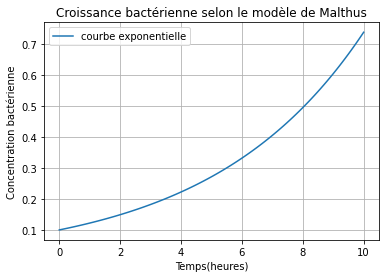

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres de la simulation
rmax = 0.2  # taux de croissance maximal (h⁻¹)
C0 = 0.1  # Concentration des cellules bactériennes au début de la simulation (10^3 cellules.mL-1)
T = 10 # durée totale de la simulation (heures)
dt = 0.1 # pas de temps (heures)
N_steps = int(T / dt)

# Simulation
time = np.linspace(0, T, N_steps)
C = C0 * np.exp(rmax * time)

# Tracé du graphique
plt.title('Croissance bactérienne selon le modèle de Malthus')  # Titre du graphique
plt.plot(time, C, label='courbe exponentielle') # Nom de la courbe
plt.xlabel('Temps(heures)') # Axe des X
plt.ylabel('Concentration bactérienne') # Axe des Y
plt.grid(True)
plt.legend()
plt.show()

Comment s’appelle ce type de courbe ?

c'est une courbe exponentielle 

En combien de temps la population double ? 
La population double en environ 3 heures 30

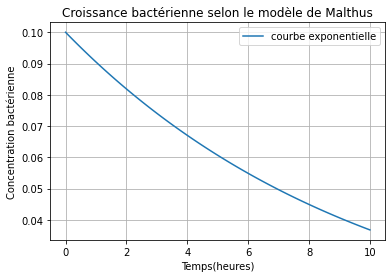

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres de la simulation
rmax = -0.1  # taux de croissance maximal (h⁻¹)
C0 = 0.1  # Concentration des cellules bactériennes au début de la simulation (10^3 cellules.mL-1)
T = 10 # durée totale de la simulation (heures)
dt = 0.1 # pas de temps (heures)
N_steps = int(T / dt)

# Simulation
time = np.linspace(0, T, N_steps)
C = C0 * np.exp(rmax * time)

# Tracé du graphique
plt.title('Croissance bactérienne selon le modèle de Malthus')  # Titre du graphique
plt.plot(time, C, label='courbe exponentielle') # Nom de la courbe
plt.xlabel('Temps(heures)') # Axe des X
plt.ylabel('Concentration bactérienne') # Axe des Y
plt.grid(True)
plt.legend()
plt.show()

Analysez les résultats. Comment évolue la concentration cellulaire lorsque r est nul ? Lorsqu’il est négatif ?

quand r est nul la population n'évolue pas 

quand r est négatif la population diminue

Quelles sont les limites de ce modèle ? Que faudrait-il ajouter pour le rendre plus réaliste ?

Les limites du modèle sont les ressources infinies et il n'y a pas de mortalité

Pour le rendre plus réalistes on pourrait ajouter des nutriments qui ont une limite et de la mortalité

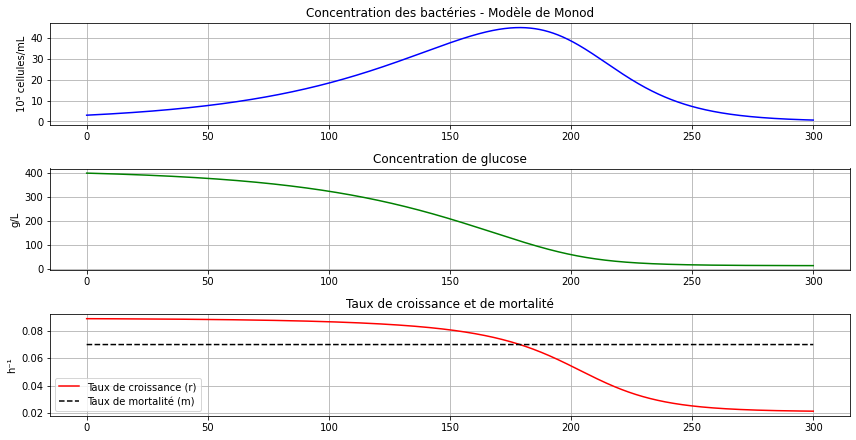

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# PARAMÈTRES DE LA SIMULATION
# ======================
T = 300          # Durée totale (heures)
dt = 0.1          # Pas de temps (heures)
N_steps = int(T / dt)  # Nombre de pas de temps

# ======================
# PARAMÈTRES DE LA SOUCHE
# ======================
rmax = 0.10      # Taux de croissance maximal (h⁻¹)
K = 50           # Affinité pour le substrat (g/L)
m0 = 0.07         # Taux de mortalité minimal (h⁻¹)
C0 = 3 # Concentration initiale de bactéries (10³ cellules/mL)

# ======================
# PARAMÈTRES DU SUBSTRAT (GLUCOSE)
# ======================
initial_glucose = 400  # Concentration initiale de glucose (g/L)
glucose_inflow = 0      # Flux entrant de glucose (g/L/h)

# ======================
# INITIALISATION DES TABLEAUX
# ======================
C = np.zeros(N_steps)          # Concentration bactérienne
glucose_level = np.zeros(N_steps)
growth_rate = np.zeros(N_steps)
mortality_rate = np.zeros(N_steps)

# ======================
# CONDITIONS INITIALES
# ======================
C[0] = C0
glucose_level[0] = initial_glucose
growth_rate[0] = rmax * glucose_level[0] / (K + glucose_level[0])
mortality_rate[0] = m0

# ======================
# SIMULATION
# ======================
for i in range(1, N_steps):
    # Calcul des taux
    r = rmax * glucose_level[i-1] / (K + glucose_level[i-1])

    # Mise à jour de la population bactérienne
    C[i] = C[i-1] + dt * (r - m0) * C[i-1]

    # Mise à jour du glucose (consommation + flux entrant)
    glucose_level[i] = glucose_level[i-1] - dt * r * C[i-1] + glucose_inflow * dt

    # Stockage des taux
    growth_rate[i] = r
    mortality_rate[i] = m0

# ======================
# AXE DES X EN HEURES
# ======================
time = np.linspace(0, T, N_steps)

# ======================
# TRACÉ DES COURBES
# ======================
plt.figure(figsize=(12, 8))

# 1. Concentration bactérienne
plt.subplot(4, 1, 1)
plt.plot(time, C, label='Nombre de bactéries', color='blue')
plt.title('Concentration des bactéries - Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.grid(True)

# 2. Concentration de glucose
plt.subplot(4, 1, 2)
plt.plot(time, glucose_level, label='Concentration de glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)

# 3. Taux de croissance ET mortalité (sur le même graphique)
plt.subplot(4, 1, 3)
plt.plot(time, growth_rate, label='Taux de croissance (r)', color='red')
plt.plot(time, mortality_rate, label='Taux de mortalité (m)', color='black', linestyle='--')  # Ligne noire en pointillé
plt.title('Taux de croissance et de mortalité')
plt.ylabel('h⁻¹')
plt.legend()  # Affiche la légende pour les deux courbes
plt.grid(True)

plt.tight_layout()
plt.show()

Décrirez l’évolution des différentes courbes.

courbe 1 : augmentation qui va ralentir par la suite et diminuer en absence de glucose

courbe 2 : forte diminution progressive car cil y a une consommation par les bactéries

courbe 3 : mortalite : constante et taux de croissance élévée qui va diminuer quand le glucose diminue

Quel est le facteur limitant dans cette expérience.

Le glucose est le facteur limitant

Pour quelles valeurs de r et m la population décroit ?

si r est inferieur à m la population décroit

Que faudrait-il pour que cette population se maintienne dans le temps ? 

Pour que cette population se maintienne dans le temps il faut une faible mortalité, une croissance suffisante et un apport de glucose maintenu dans le temps

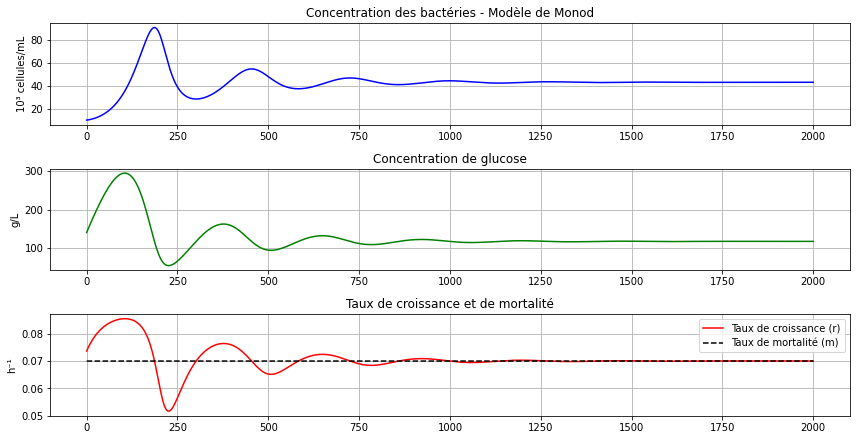

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# ======================
# PARAMÈTRES DE LA SIMULATION
# ======================
T = 2000          # Durée totale (heures)
dt = 0.1          # Pas de temps (heures)
N_steps = int(T / dt)  # Nombre de pas de temps

# ======================
# PARAMÈTRES DE LA SOUCHE
# ======================
rmax = 0.10      # Taux de croissance maximal (h⁻¹)
K = 50           # Affinité pour le substrat (g/L)
m0 = 0.07         # Taux de mortalité minimal (h⁻¹)
C0 = 10 # Concentration initiale de bactéries (10³ cellules/mL)

# ======================
# PARAMÈTRES DU SUBSTRAT (GLUCOSE)
# ======================
initial_glucose = 140  # Concentration initiale de glucose (g/L)
glucose_inflow = 3      # Flux entrant de glucose (g/L/h)

# ======================
# INITIALISATION DES TABLEAUX
# ======================
C = np.zeros(N_steps)          # Concentration bactérienne
glucose_level = np.zeros(N_steps)
growth_rate = np.zeros(N_steps)
mortality_rate = np.zeros(N_steps)

# ======================
# CONDITIONS INITIALES
# ======================
C[0] = C0
glucose_level[0] = initial_glucose
growth_rate[0] = rmax * glucose_level[0] / (K + glucose_level[0])
mortality_rate[0] = m0

# ======================
# SIMULATION
# ======================
for i in range(1, N_steps):
    # Calcul des taux
    r = rmax * glucose_level[i-1] / (K + glucose_level[i-1])

    # Mise à jour de la population bactérienne
    C[i] = C[i-1] + dt * (r - m0) * C[i-1]

    # Mise à jour du glucose (consommation + flux entrant)
    glucose_level[i] = glucose_level[i-1] - dt * r * C[i-1] + glucose_inflow * dt

    # Stockage des taux
    growth_rate[i] = r
    mortality_rate[i] = m0

# ======================
# AXE DES X EN HEURES
# ======================
time = np.linspace(0, T, N_steps)

# ======================
# TRACÉ DES COURBES
# ======================
plt.figure(figsize=(12, 8))

# 1. Concentration bactérienne
plt.subplot(4, 1, 1)
plt.plot(time, C, label='Nombre de bactéries', color='blue')
plt.title('Concentration des bactéries - Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.grid(True)

# 2. Concentration de glucose
plt.subplot(4, 1, 2)
plt.plot(time, glucose_level, label='Concentration de glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)

# 3. Taux de croissance ET mortalité (sur le même graphique)
plt.subplot(4, 1, 3)
plt.plot(time, growth_rate, label='Taux de croissance (r)', color='red')
plt.plot(time, mortality_rate, label='Taux de mortalité (m)', color='black', linestyle='--')  # Ligne noire en pointillé
plt.title('Taux de croissance et de mortalité')
plt.ylabel('h⁻¹')
plt.legend()  # Affiche la légende pour les deux courbes
plt.grid(True)

plt.tight_layout()
plt.show()

Décrivez les courbes 

on observe des oscillations avant une stabilisation dans les 3 courbes 

Pourquoi la population bactérienne présente des fluctuations marquée avant de se stabiliser ?

La population bactérienne présente des fluctuations marquée avant de se stabiliser car en augmentant glucose_inflow la population consomme le glucose, le glucose revient progressivement et ainsi les bactéries repoussent

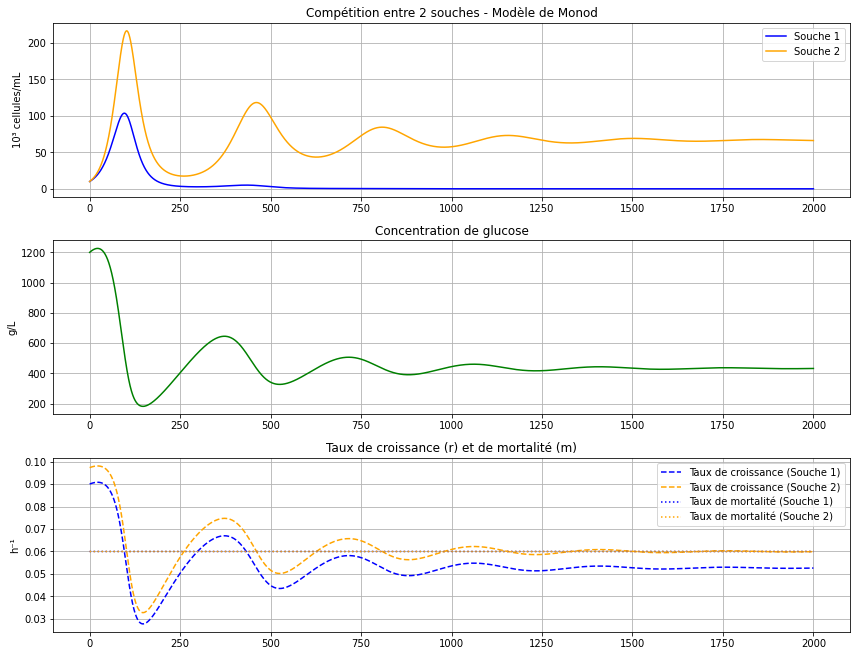

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# Paramètres pour la souche 1
# =============================================
rmax_1 = 0.15      # Taux de croissance maximal (souche 1)
m0_1 = 0.06      # Taux de mortalité de base (souche 1)
K_1 = 800        # Constante de demi-saturation (souche 1)

# =============================================
# Paramètres pour la souche 2
# =============================================
rmax_2 = 0.15      # Taux de croissance maximal (souche 2)
m0_2 = 0.06      # Taux de mortalité de base (souche 2)
K_2 = 650      # Constante de demi-saturation (souche 2) - affinité plus élevée pour le glucose

# =============================================
# Paramètres du glucose
# =============================================
initial_glucose = 1200   # Quantité initiale de glucose
glucose_inflow = 4      # Flux entrant de glucose (0 = système fermé)

# =============================================
# Conditions initiales
# =============================================
C0_1 = 10  # Concentration initiale de la souche 1
C0_2 = 10   # Concentration initiale de la souche 2

# =============================================
# Paramètres de la simulation
# =============================================
dt = 0.1         # Pas de temps
T = 2000         # Durée totale de la simulation
N_steps = int(T / dt)# Nombre de pas de temps

# =============================================
# Initialisation des tableaux
# =============================================
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)
mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)

# Conditions initiales
C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose
growth_rate_1[0] = rmax_1 * glucose_level[0] / (K_1 + glucose_level[0])
growth_rate_2[0] = rmax_2 * glucose_level[0] / (K_2 + glucose_level[0])
mortality_rate_1[0] = m0_1
mortality_rate_2[0] = m0_2

# =============================================
# Simulation
# =============================================
for i in range(1, N_steps):
    # Calcul des taux de croissance pour chaque souche (modèle de Monod)
    r_1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    # Mortalité variable (augmente si le glucose est faible)
    #m_1 = m0_1 + 0.01 * (1 - glucose_level[i-1] / initial_glucose)
    #m_2 = m0_2 + 0.01 * (1 - glucose_level[i-1] / initial_glucose)

      # Mortalité constante
    m_1 = m0_1 
    m_2 = m0_2
    
    # Mise à jour des populations bactériennes
    C1[i] = C1[i-1] + dt * (r_1 - m_1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r_2 - m_2) * C2[i-1]

    # Consommation totale de glucose (somme des consommations des deux souches)
    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1])
    glucose_level[i] = glucose_level[i-1] - dt * glucose_consumption + glucose_inflow * dt

    # Stockage des taux
    growth_rate_1[i] = r_1
    growth_rate_2[i] = r_2
    mortality_rate_1[i] = m_1
    mortality_rate_2[i] = m_2

# =============================================
# Temps pour l'axe des abscisses
# =============================================
time = np.linspace(0, T, N_steps)

# =============================================
# Tracé des courbes
# =============================================
plt.figure(figsize=(12, 12))

# Population des bactéries
plt.subplot(4, 1, 1)
plt.plot(time, C1, label='Souche 1', color='blue')
plt.plot(time, C2, label='Souche 2', color='orange')
plt.title('Compétition entre 2 souches - Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.legend()
plt.grid(True)

# Niveau de glucose
plt.subplot(4, 1, 2)
plt.plot(time, glucose_level, label='Glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)

# Taux de croissance et mortalité
plt.subplot(4, 1, 3)
plt.plot(time, growth_rate_1, label='Taux de croissance (Souche 1)', color='blue', linestyle='--')
plt.plot(time, growth_rate_2, label='Taux de croissance (Souche 2)', color='orange', linestyle='--')
plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
plt.title('Taux de croissance (r) et de mortalité (m)')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)

# Taux de mortalité
#plt.subplot(4, 1, 4)
#plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
#plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
#plt.title('Taux de mortalité (m) au fil du temps')
#plt.xlabel('Temps')
#plt.ylabel('Taux de mortalité (m)')
#plt.legend()
#plt.grid(True)

plt.tight_layout()
plt.show()

Décrivez les courbes.  

On observe des oscillations un peu plus marquées avec une stabilisation par la suite, en adéquation avec la concentration de glucose 

la souche 1 devient constante très rapidement dans la 1ere courbe

Quel est le résultat de la concurrence sur le devenir des populations ?

La souche 2 est meilleure car elle a une meilleure affinité pour le glucose ( son k est plus faible : 650)

Modifiez le paramètre m de la souche 1. A partir de quelle valeur celle-ci l’emporte sur la souche 2 ?

Si elle a un k plus faible que celui de la souche 2, donc inferieur à 650, elle l'emportera sur la souche 2 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# Paramètres pour la souche 1
# =============================================
rmax_1 = 0.15      # Taux de croissance maximal (souche 1)
m0_1 = 0.06      # Taux de mortalité de base (souche 1)
K_1 = 550        # Constante de demi-saturation (souche 1)

# =============================================
# Paramètres pour la souche 2
# =============================================
rmax_2 = 0.15      # Taux de croissance maximal (souche 2)
m0_2 = 0.06      # Taux de mortalité de base (souche 2)
K_2 = 650      # Constante de demi-saturation (souche 2) - affinité plus élevée pour le glucose

# =============================================
# Paramètres du glucose
# =============================================
initial_glucose = 1200   # Quantité initiale de glucose
glucose_inflow = 4      # Flux entrant de glucose (0 = système fermé)

# =============================================
# Conditions initiales
# =============================================
C0_1 = 10  # Concentration initiale de la souche 1
C0_2 = 10   # Concentration initiale de la souche 2

# =============================================
# Paramètres de la simulation
# =============================================
dt = 0.1         # Pas de temps
T = 2000         # Durée totale de la simulation
N_steps = int(T / dt)# Nombre de pas de temps

# =============================================
# Initialisation des tableaux
# =============================================
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)
mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)

# Conditions initiales
C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose
growth_rate_1[0] = rmax_1 * glucose_level[0] / (K_1 + glucose_level[0])
growth_rate_2[0] = rmax_2 * glucose_level[0] / (K_2 + glucose_level[0])
mortality_rate_1[0] = m0_1
mortality_rate_2[0] = m0_2

# =============================================
# Simulation
# =============================================
for i in range(1, N_steps):
    # Calcul des taux de croissance pour chaque souche (modèle de Monod)
    r_1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    # Mortalité variable (augmente si le glucose est faible)
    #m_1 = m0_1 + 0.01 * (1 - glucose_level[i-1] / initial_glucose)
    #m_2 = m0_2 + 0.01 * (1 - glucose_level[i-1] / initial_glucose)

      # Mortalité constante
    m_1 = m0_1 
    m_2 = m0_2
    
    # Mise à jour des populations bactériennes
    C1[i] = C1[i-1] + dt * (r_1 - m_1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r_2 - m_2) * C2[i-1]

    # Consommation totale de glucose (somme des consommations des deux souches)
    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1])
    glucose_level[i] = glucose_level[i-1] - dt * glucose_consumption + glucose_inflow * dt

    # Stockage des taux
    growth_rate_1[i] = r_1
    growth_rate_2[i] = r_2
    mortality_rate_1[i] = m_1
    mortality_rate_2[i] = m_2

# =============================================
# Temps pour l'axe des abscisses
# =============================================
time = np.linspace(0, T, N_steps)

# =============================================
# Tracé des courbes
# =============================================
plt.figure(figsize=(12, 12))

# Population des bactéries
plt.subplot(4, 1, 1)
plt.plot(time, C1, label='Souche 1', color='blue')
plt.plot(time, C2, label='Souche 2', color='orange')
plt.title('Compétition entre 2 souches - Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.legend()
plt.grid(True)

# Niveau de glucose
plt.subplot(4, 1, 2)
plt.plot(time, glucose_level, label='Glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)

# Taux de croissance et mortalité
plt.subplot(4, 1, 3)
plt.plot(time, growth_rate_1, label='Taux de croissance (Souche 1)', color='blue', linestyle='--')
plt.plot(time, growth_rate_2, label='Taux de croissance (Souche 2)', color='orange', linestyle='--')
plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
plt.title('Taux de croissance (r) et de mortalité (m)')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)

# Taux de mortalité
#plt.subplot(4, 1, 4)
#plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
#plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
#plt.title('Taux de mortalité (m) au fil du temps')
#plt.xlabel('Temps')
#plt.ylabel('Taux de mortalité (m)')
#plt.legend()
#plt.grid(True)

plt.tight_layout()
plt.show()

Avec un k plus faible, la souche 1 est gagnante 

Quelles sont les conditions d’un équilibres où les 2 souches coexistent ? 

Les conditions d'un equilibre ou les 2 souches coexistent : des taux de croissance et de mortalites proches, un partage des ressources et aucune n'a des avantages par rapport à l'autre






Modifier le script afin d’ajouter une 3eme souche : 

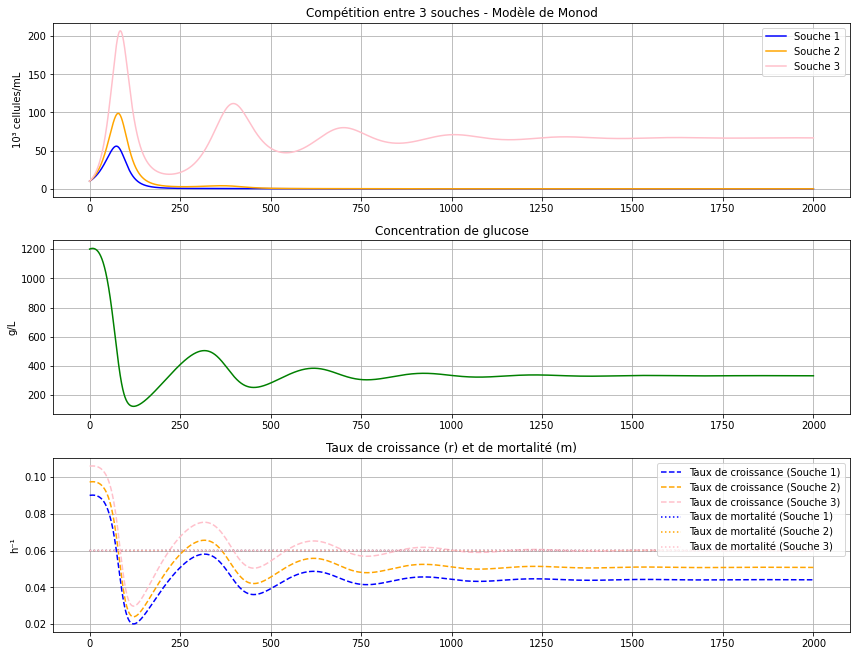

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# Paramètres pour la souche 1
# =============================================
rmax_1 = 0.15      # Taux de croissance maximal (souche 1)
m0_1 = 0.06      # Taux de mortalité de base (souche 1)
K_1 = 800        # Constante de demi-saturation (souche 1)

# =============================================
# Paramètres pour la souche 2
# =============================================
rmax_2 = 0.15      # Taux de croissance maximal (souche 2)
m0_2 = 0.06      # Taux de mortalité de base (souche 2)
K_2 = 650      # Constante de demi-saturation (souche 2) - affinité plus élevée pour le glucose

# =============================================
# Paramètres pour la souche 3
# =============================================
rmax_3 = 0.15      # Taux de croissance maximal (souche 3)
m0_3 = 0.06      # Taux de mortalité de base (souche 3)
K_3 = 500      # Constante de demi-saturation (souche 3) - affinité plus élevée pour le glucose

# =============================================
# Paramètres du glucose
# =============================================
initial_glucose = 1200   # Quantité initiale de glucose
glucose_inflow = 4      # Flux entrant de glucose (0 = système fermé)

# =============================================
# Conditions initiales
# =============================================
C0_1 = 10  # Concentration initiale de la souche 1
C0_2 = 10   # Concentration initiale de la souche 2
C0_3 = 10   # Concentration initiale de la souche 3

# =============================================
# Paramètres de la simulation
# =============================================
dt = 0.1         # Pas de temps
T = 2000         # Durée totale de la simulation
N_steps = int(T / dt)# Nombre de pas de temps

# =============================================
# Initialisation des tableaux
# =============================================
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
C3 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)
growth_rate_3 = np.zeros(N_steps)
mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)
mortality_rate_3 = np.zeros(N_steps)

# Conditions initiales
C1[0] = C0_1
C2[0] = C0_2
C3[0] = C0_3
glucose_level[0] = initial_glucose
growth_rate_1[0] = rmax_1 * glucose_level[0] / (K_1 + glucose_level[0])
growth_rate_2[0] = rmax_2 * glucose_level[0] / (K_2 + glucose_level[0])
growth_rate_3[0] = rmax_3 * glucose_level[0] / (K_3 + glucose_level[0])
mortality_rate_1[0] = m0_1
mortality_rate_2[0] = m0_2
mortality_rate_3[0] = m0_3

# =============================================
# Simulation
# =============================================
for i in range(1, N_steps):
    # Calcul des taux de croissance pour chaque souche (modèle de Monod)
    r_1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])
    r_3 = rmax_3 * glucose_level[i-1] / (K_3 + glucose_level[i-1])

    # Mortalité variable (augmente si le glucose est faible)
    #m_1 = m0_1 + 0.01 * (1 - glucose_level[i-1] / initial_glucose)
    #m_2 = m0_2 + 0.01 * (1 - glucose_level[i-1] / initial_glucose)
    #m_3 = m0_3 + 0.01 * (1 - glucose_level[i-1] / initial_glucose)

      # Mortalité constante
    m_1 = m0_1 
    m_2 = m0_2
    m_3 = m0_3
    
    # Mise à jour des populations bactériennes
    C1[i] = C1[i-1] + dt * (r_1 - m_1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r_2 - m_2) * C2[i-1]
    C3[i] = C3[i-1] + dt * (r_3 - m_3) * C3[i-1]

    # Consommation totale de glucose (somme des consommations des trois souches)
    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1]+ r_3 * C3[i-1])
    glucose_level[i] = glucose_level[i-1] - dt * glucose_consumption + glucose_inflow * dt

    # Stockage des taux
    growth_rate_1[i] = r_1
    growth_rate_2[i] = r_2
    growth_rate_3[i] = r_3
    mortality_rate_1[i] = m_1
    mortality_rate_2[i] = m_2
    mortality_rate_3[i] = m_3

# =============================================
# Temps pour l'axe des abscisses
# =============================================
time = np.linspace(0, T, N_steps)

# =============================================
# Tracé des courbes
# =============================================
plt.figure(figsize=(12, 12))

# Population des bactéries
plt.subplot(4, 1, 1)
plt.plot(time, C1, label='Souche 1', color='blue')
plt.plot(time, C2, label='Souche 2', color='orange')
plt.plot(time, C3, label='Souche 3', color='pink')
plt.title('Compétition entre 3 souches - Modèle de Monod')
plt.ylabel('10³ cellules/mL')
plt.legend()
plt.grid(True)

# Niveau de glucose
plt.subplot(4, 1, 2)
plt.plot(time, glucose_level, label='Glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.grid(True)

# Taux de croissance et mortalité
plt.subplot(4, 1, 3)
plt.plot(time, growth_rate_1, label='Taux de croissance (Souche 1)', color='blue', linestyle='--')
plt.plot(time, growth_rate_2, label='Taux de croissance (Souche 2)', color='orange', linestyle='--')
plt.plot(time, growth_rate_3, label='Taux de croissance (Souche 3)', color='pink', linestyle='--')
plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
plt.plot(time, mortality_rate_3, label='Taux de mortalité (Souche 3)', color='pink', linestyle=':')
plt.title('Taux de croissance (r) et de mortalité (m)')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)

# Taux de mortalité
#plt.subplot(4, 1, 4)
#plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
#plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
#plt.plot(time, mortality_rate_3, label='Taux de mortalité (Souche 3)', color='pink', linestyle=':')
#plt.title('Taux de mortalité (m) au fil du temps')
#plt.xlabel('Temps')
#plt.ylabel('Taux de mortalité (m)')
#plt.legend()
#plt.grid(True)

plt.tight_layout()
plt.show()

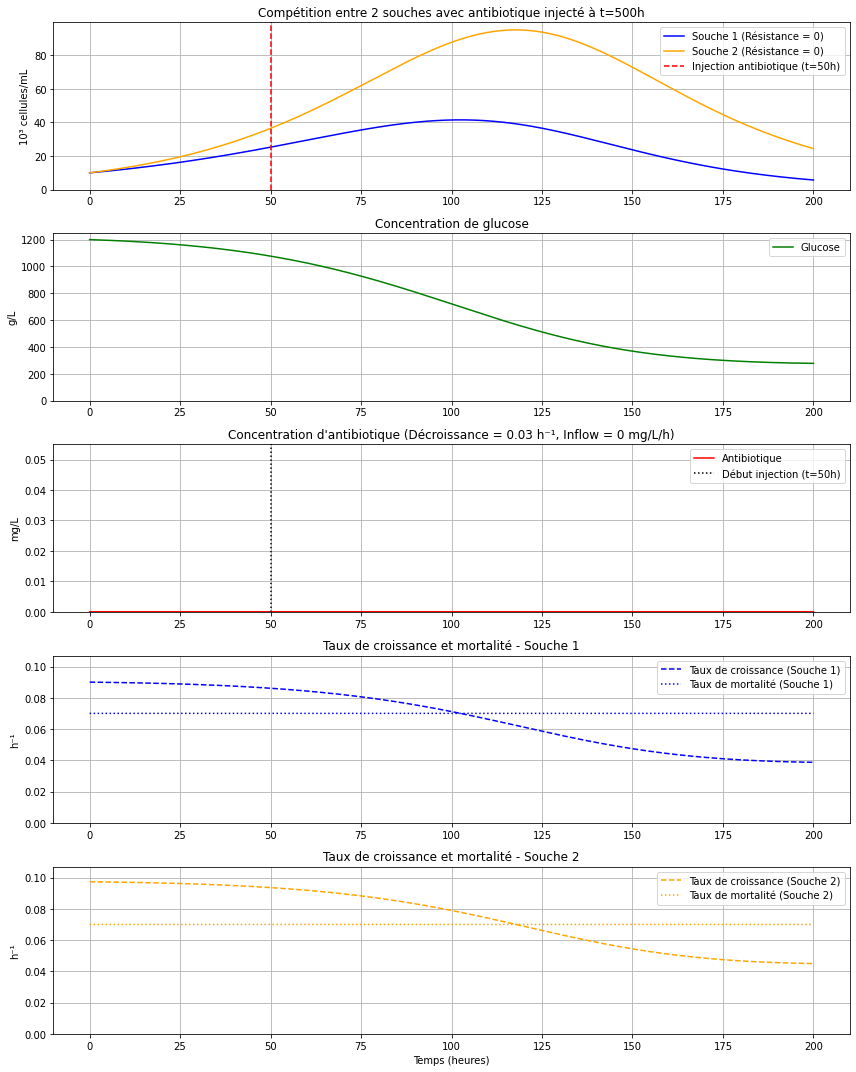

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# PARAMÈTRES POUR LES SOUCHES
# =============================================
# Souche 1
rmax_1 = 0.15      # Taux de croissance maximal (h⁻¹)
m0_1 = 0.07        # Taux de mortalité de base (h⁻¹)
K_1 = 800              # Constante de demi-saturation (g/L)
resistance_1 = 0  # Résistance à l'antibiotique (0 = aucune, 1 = totale)

# Souche 2
rmax_2 = 0.15      # Taux de croissance maximal (h⁻¹)
m0_2 = 0.07        # Taux de mortalité de base (h⁻¹)
K_2 = 650          # Constante de demi-saturation (g/L)
resistance_2 = 0 # Résistance à l'antibiotique

# =============================================
# PARAMÈTRES DU GLUCOSE
# =============================================
initial_glucose = 1200   # Concentration initiale de glucose (g/L)
glucose_inflow = 1      # Flux entrant de glucose (g/L/h)

# =============================================
# PARAMÈTRES DE L'ANTIBIOTIQUE
# =============================================
initial_antibiotic = 0   # Concentration initiale d'antibiotique (mg/L)
antibiotic_intensity = 3 # Intensité (0 = aucun effet, 1 = mortalité doublée)
antibiotic_decay = 0.03    # Taux de décroissance naturelle (h⁻¹)
antibiotic_inflow = 0      # Flux entrant d'antibiotique (mg/L/h)
antibiotic_start_time = 50  # Temps (en heures) avant l'injection

# =============================================
# CONDITIONS INITIALES
# =============================================
C0_1 = 10  # Concentration initiale de la souche 1 (10³ cellules/mL)
C0_2 = 10  # Concentration initiale de la souche 2 (10³ cellules/mL)

# =============================================
# PARAMÈTRES DE LA SIMULATION
# =============================================
dt = 0.1          # Pas de temps (h)
T = 200          # Durée totale (h)
N_steps = int(T / dt)

# =============================================
# INITIALISATION DES TABLEAUX
# =============================================
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
antibiotic_level = np.zeros(N_steps)
growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)
mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)

# Conditions initiales
C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose
antibiotic_level[0] = 0
growth_rate_1[0] = rmax_1 * glucose_level[0] / (K_1 + glucose_level[0])
growth_rate_2[0] = rmax_2 * glucose_level[0] / (K_2 + glucose_level[0])
mortality_rate_1[0] = m0_1
mortality_rate_2[0] = m0_2

# =============================================
# SIMULATION
# =============================================
for i in range(1, N_steps):
    current_time = i * dt

    # Calcul des taux de croissance
    r_1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    # Mise à jour de l'antibiotique (CORRIGÉ)
    if current_time < antibiotic_start_time:
        antibiotic_level[i] = 0
    else:
        if antibiotic_level[i-1] == 0:  # Premier pas après l'injection
            antibiotic_level[i] = initial_antibiotic
        else:
            antibiotic_level[i] = antibiotic_level[i-1] * (1 - antibiotic_decay * dt) + antibiotic_inflow * dt

    # Effet de l'antibiotique sur la mortalité
    if antibiotic_level[i] > 0:
        antibiotic_effect_1 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 - resistance_1)
        antibiotic_effect_2 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 - resistance_2)
    else:
        antibiotic_effect_1 = 0
        antibiotic_effect_2 = 0

    m_1 = m0_1 * (1 + antibiotic_effect_1)
    m_2 = m0_2 * (1 + antibiotic_effect_2)

    # Mise à jour des populations
    C1[i] = C1[i-1] + dt * (r_1 - m_1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r_2 - m_2) * C2[i-1]

    # Consommation de glucose
    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1])
    glucose_level[i] = glucose_level[i-1] - dt * glucose_consumption + glucose_inflow * dt

    # Stockage des taux
    growth_rate_1[i] = r_1
    growth_rate_2[i] = r_2
    mortality_rate_1[i] = m_1
    mortality_rate_2[i] = m_2

# =============================================
# TEMPS POUR L'AXE DES ABCISSES
# =============================================
time = np.linspace(0, T, N_steps)

# =============================================
# CALCUL DES ÉCHELLES COMMUNES POUR LES TAUX
# =============================================
# Trouver le maximum global pour les taux de croissance et mortalité
max_growth = max(np.max(growth_rate_1), np.max(growth_rate_2))
max_mortality = max(np.max(mortality_rate_1), np.max(mortality_rate_2))
y_max_rates = max(max_growth, max_mortality) * 1.1  # +10% de marge

# =============================================
# TRACÉ DES COURBES
# =============================================
plt.figure(figsize=(12, 15))

# 1. Populations bactériennes
plt.subplot(5, 1, 1)
plt.plot(time, C1, label=f'Souche 1 (Résistance = {resistance_1})', color='blue')
plt.plot(time, C2, label=f'Souche 2 (Résistance = {resistance_2})', color='orange')
plt.axvline(x=antibiotic_start_time, color='red', linestyle='--', label=f'Injection antibiotique (t={antibiotic_start_time}h)')
plt.title('Compétition entre 2 souches avec antibiotique injecté à t=500h')
plt.ylabel('10³ cellules/mL')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 2. Concentration de glucose
plt.subplot(5, 1, 2)
plt.plot(time, glucose_level, label='Glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 3. Concentration d'antibiotique
plt.subplot(5, 1, 3)
plt.plot(time, antibiotic_level, label='Antibiotique', color='red')
plt.axvline(x=antibiotic_start_time, color='black', linestyle=':', label=f'Début injection (t={antibiotic_start_time}h)')
plt.title(f'Concentration d\'antibiotique (Décroissance = {antibiotic_decay} h⁻¹, Inflow = {antibiotic_inflow} mg/L/h)')
plt.ylabel('mg/L')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 4. Taux de croissance et mortalité (Souche 1)
plt.subplot(5, 1, 4)
plt.plot(time, growth_rate_1, label='Taux de croissance (Souche 1)', color='blue', linestyle='--')
plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
plt.title('Taux de croissance et mortalité - Souche 1')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0, top=y_max_rates)  # Échelle commune

# 5. Taux de croissance et mortalité (Souche 2)
plt.subplot(5, 1, 5)
plt.plot(time, growth_rate_2, label='Taux de croissance (Souche 2)', color='orange', linestyle='--')
plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
plt.title('Taux de croissance et mortalité - Souche 2')
plt.xlabel('Temps (heures)')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0, top=y_max_rates)  # Même échelle que le graphique 4

plt.tight_layout()
plt.show()

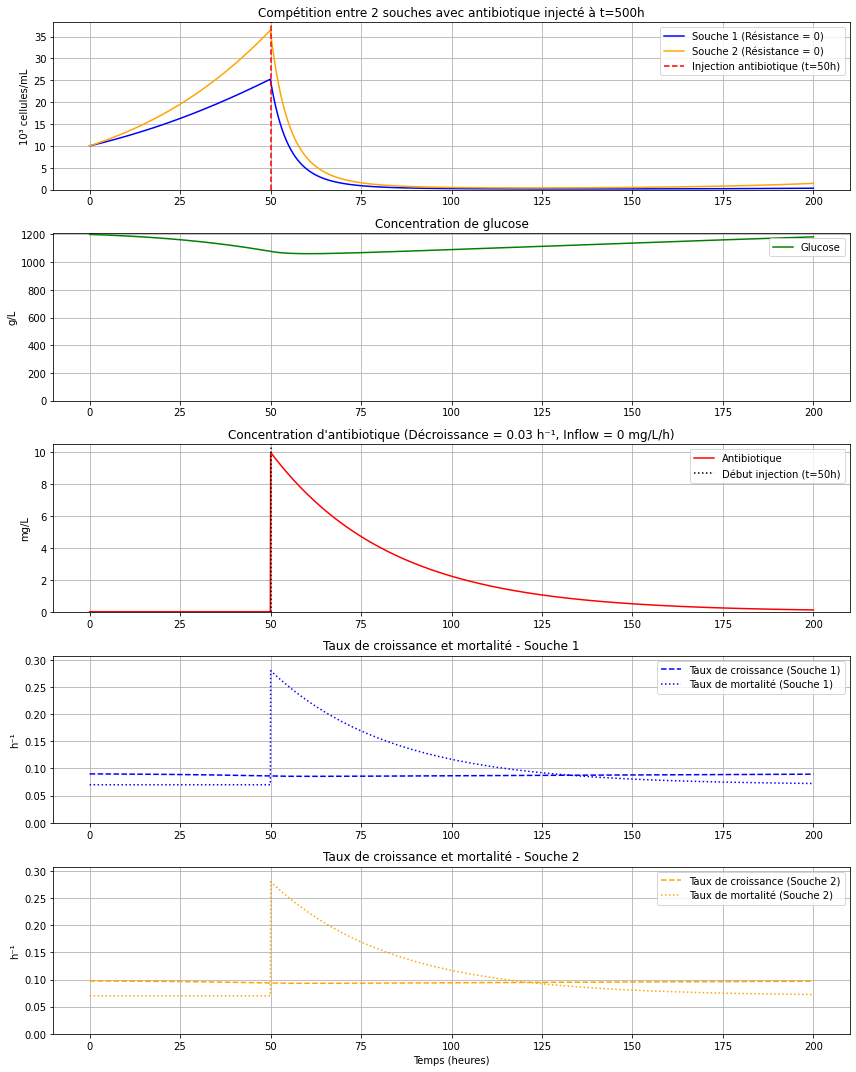

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# PARAMÈTRES POUR LES SOUCHES
# =============================================
# Souche 1
rmax_1 = 0.15      # Taux de croissance maximal (h⁻¹)
m0_1 = 0.07        # Taux de mortalité de base (h⁻¹)
K_1 = 800              # Constante de demi-saturation (g/L)
resistance_1 = 0   # Résistance à l'antibiotique (0 = aucune, 1 = totale)

# Souche 2
rmax_2 = 0.15      # Taux de croissance maximal (h⁻¹)
m0_2 = 0.07        # Taux de mortalité de base (h⁻¹)
K_2 = 650          # Constante de demi-saturation (g/L)
resistance_2 = 0 # Résistance à l'antibiotique

# =============================================
# PARAMÈTRES DU GLUCOSE
# =============================================
initial_glucose = 1200   # Concentration initiale de glucose (g/L)
glucose_inflow = 1      # Flux entrant de glucose (g/L/h)

# =============================================
# PARAMÈTRES DE L'ANTIBIOTIQUE
# =============================================
initial_antibiotic = 10   # Concentration initiale d'antibiotique (mg/L)
antibiotic_intensity = 3 # Intensité (0 = aucun effet, 1 = mortalité doublée)
antibiotic_decay = 0.03    # Taux de décroissance naturelle (h⁻¹)
antibiotic_inflow = 0      # Flux entrant d'antibiotique (mg/L/h)
antibiotic_start_time = 50  # Temps (en heures) avant l'injection

# =============================================
# CONDITIONS INITIALES
# =============================================
C0_1 = 10  # Concentration initiale de la souche 1 (10³ cellules/mL)
C0_2 = 10  # Concentration initiale de la souche 2 (10³ cellules/mL)

# =============================================
# PARAMÈTRES DE LA SIMULATION
# =============================================
dt = 0.1          # Pas de temps (h)
T = 200         # Durée totale (h)
N_steps = int(T / dt)

# =============================================
# INITIALISATION DES TABLEAUX
# =============================================
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
antibiotic_level = np.zeros(N_steps)
growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)
mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)

# Conditions initiales
C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose
antibiotic_level[0] = 0
growth_rate_1[0] = rmax_1 * glucose_level[0] / (K_1 + glucose_level[0])
growth_rate_2[0] = rmax_2 * glucose_level[0] / (K_2 + glucose_level[0])
mortality_rate_1[0] = m0_1
mortality_rate_2[0] = m0_2

# =============================================
# SIMULATION
# =============================================
for i in range(1, N_steps):
    current_time = i * dt

    # Calcul des taux de croissance
    r_1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    # Mise à jour de l'antibiotique (CORRIGÉ)
    if current_time < antibiotic_start_time:
        antibiotic_level[i] = 0
    else:
        if antibiotic_level[i-1] == 0:  # Premier pas après l'injection
            antibiotic_level[i] = initial_antibiotic
        else:
            antibiotic_level[i] = antibiotic_level[i-1] * (1 - antibiotic_decay * dt) + antibiotic_inflow * dt

    # Effet de l'antibiotique sur la mortalité
    if antibiotic_level[i] > 0:
        antibiotic_effect_1 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 - resistance_1)
        antibiotic_effect_2 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 - resistance_2)
    else:
        antibiotic_effect_1 = 0
        antibiotic_effect_2 = 0

    m_1 = m0_1 * (1 + antibiotic_effect_1)
    m_2 = m0_2 * (1 + antibiotic_effect_2)

    # Mise à jour des populations
    C1[i] = C1[i-1] + dt * (r_1 - m_1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r_2 - m_2) * C2[i-1]

    # Consommation de glucose
    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1])
    glucose_level[i] = glucose_level[i-1] - dt * glucose_consumption + glucose_inflow * dt

    # Stockage des taux
    growth_rate_1[i] = r_1
    growth_rate_2[i] = r_2
    mortality_rate_1[i] = m_1
    mortality_rate_2[i] = m_2

# =============================================
# TEMPS POUR L'AXE DES ABCISSES
# =============================================
time = np.linspace(0, T, N_steps)

# =============================================
# CALCUL DES ÉCHELLES COMMUNES POUR LES TAUX
# =============================================
# Trouver le maximum global pour les taux de croissance et mortalité
max_growth = max(np.max(growth_rate_1), np.max(growth_rate_2))
max_mortality = max(np.max(mortality_rate_1), np.max(mortality_rate_2))
y_max_rates = max(max_growth, max_mortality) * 1.1  # +10% de marge

# =============================================
# TRACÉ DES COURBES
# =============================================
plt.figure(figsize=(12, 15))

# 1. Populations bactériennes
plt.subplot(5, 1, 1)
plt.plot(time, C1, label=f'Souche 1 (Résistance = {resistance_1})', color='blue')
plt.plot(time, C2, label=f'Souche 2 (Résistance = {resistance_2})', color='orange')
plt.axvline(x=antibiotic_start_time, color='red', linestyle='--', label=f'Injection antibiotique (t={antibiotic_start_time}h)')
plt.title('Compétition entre 2 souches avec antibiotique injecté à t=500h')
plt.ylabel('10³ cellules/mL')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 2. Concentration de glucose
plt.subplot(5, 1, 2)
plt.plot(time, glucose_level, label='Glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 3. Concentration d'antibiotique
plt.subplot(5, 1, 3)
plt.plot(time, antibiotic_level, label='Antibiotique', color='red')
plt.axvline(x=antibiotic_start_time, color='black', linestyle=':', label=f'Début injection (t={antibiotic_start_time}h)')
plt.title(f'Concentration d\'antibiotique (Décroissance = {antibiotic_decay} h⁻¹, Inflow = {antibiotic_inflow} mg/L/h)')
plt.ylabel('mg/L')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 4. Taux de croissance et mortalité (Souche 1)
plt.subplot(5, 1, 4)
plt.plot(time, growth_rate_1, label='Taux de croissance (Souche 1)', color='blue', linestyle='--')
plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
plt.title('Taux de croissance et mortalité - Souche 1')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0, top=y_max_rates)  # Échelle commune

# 5. Taux de croissance et mortalité (Souche 2)
plt.subplot(5, 1, 5)
plt.plot(time, growth_rate_2, label='Taux de croissance (Souche 2)', color='orange', linestyle='--')
plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
plt.title('Taux de croissance et mortalité - Souche 2')
plt.xlabel('Temps (heures)')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0, top=y_max_rates)  # Même échelle que le graphique 4

plt.tight_layout()
plt.show()

Initialement il n’y a pas d’antibiotique dans la simulation. Nous allons en mettre en paramétrant  initial_antibiotic =10. A 
    • Décrivez les résultats
    

En paramétrant initial_antibiotic =10, l'antobiotique augmente la mortalité ce qui fait chuter les populations

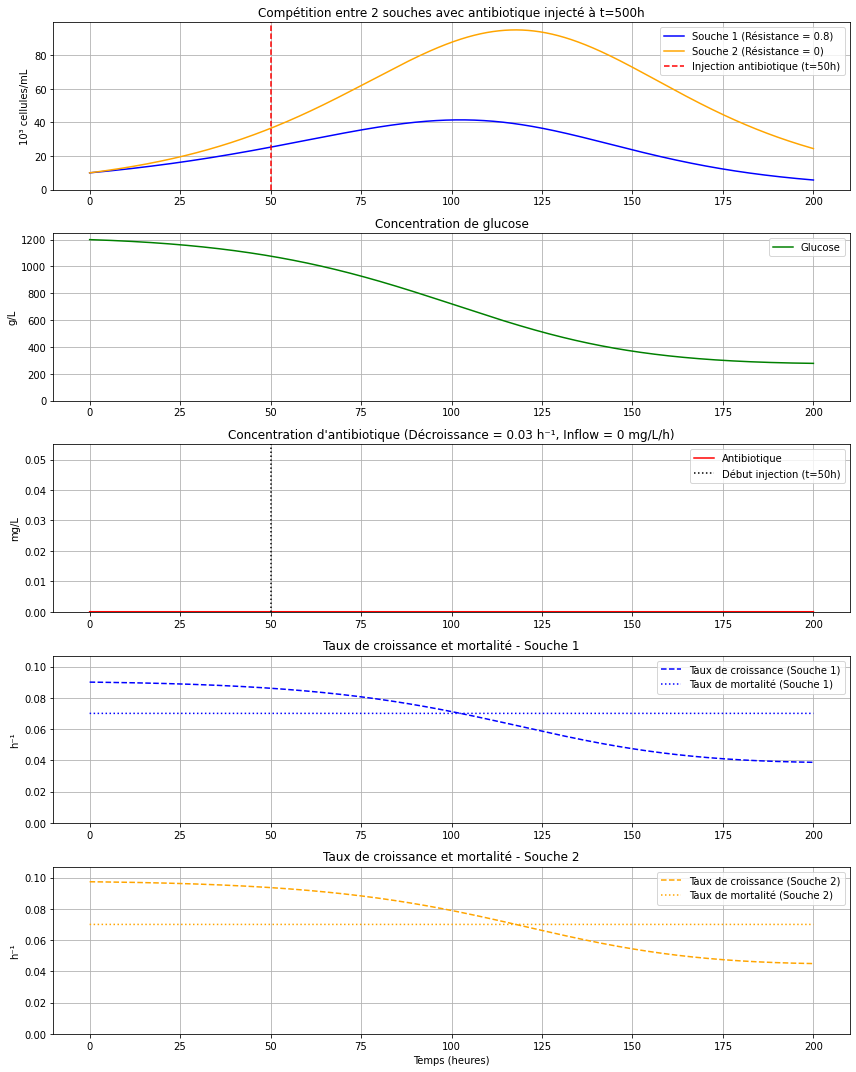

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# PARAMÈTRES POUR LES SOUCHES
# =============================================
# Souche 1
rmax_1 = 0.15      # Taux de croissance maximal (h⁻¹)
m0_1 = 0.07        # Taux de mortalité de base (h⁻¹)
K_1 = 800              # Constante de demi-saturation (g/L)
resistance_1 = 0.8  # Résistance à l'antibiotique (0 = aucune, 1 = totale)

# Souche 2
rmax_2 = 0.15      # Taux de croissance maximal (h⁻¹)
m0_2 = 0.07        # Taux de mortalité de base (h⁻¹)
K_2 = 650          # Constante de demi-saturation (g/L)
resistance_2 = 0 # Résistance à l'antibiotique

# =============================================
# PARAMÈTRES DU GLUCOSE
# =============================================
initial_glucose = 1200   # Concentration initiale de glucose (g/L)
glucose_inflow = 1      # Flux entrant de glucose (g/L/h)

# =============================================
# PARAMÈTRES DE L'ANTIBIOTIQUE
# =============================================
initial_antibiotic = 0   # Concentration initiale d'antibiotique (mg/L)
antibiotic_intensity = 3 # Intensité (0 = aucun effet, 1 = mortalité doublée)
antibiotic_decay = 0.03    # Taux de décroissance naturelle (h⁻¹)
antibiotic_inflow = 0      # Flux entrant d'antibiotique (mg/L/h)
antibiotic_start_time = 50  # Temps (en heures) avant l'injection

# =============================================
# CONDITIONS INITIALES
# =============================================
C0_1 = 10  # Concentration initiale de la souche 1 (10³ cellules/mL)
C0_2 = 10  # Concentration initiale de la souche 2 (10³ cellules/mL)

# =============================================
# PARAMÈTRES DE LA SIMULATION
# =============================================
dt = 0.1          # Pas de temps (h)
T = 200          # Durée totale (h)
N_steps = int(T / dt)

# =============================================
# INITIALISATION DES TABLEAUX
# =============================================
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
antibiotic_level = np.zeros(N_steps)
growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)
mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)

# Conditions initiales
C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose
antibiotic_level[0] = 0
growth_rate_1[0] = rmax_1 * glucose_level[0] / (K_1 + glucose_level[0])
growth_rate_2[0] = rmax_2 * glucose_level[0] / (K_2 + glucose_level[0])
mortality_rate_1[0] = m0_1
mortality_rate_2[0] = m0_2

# =============================================
# SIMULATION
# =============================================
for i in range(1, N_steps):
    current_time = i * dt

    # Calcul des taux de croissance
    r_1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    # Mise à jour de l'antibiotique (CORRIGÉ)
    if current_time < antibiotic_start_time:
        antibiotic_level[i] = 0
    else:
        if antibiotic_level[i-1] == 0:  # Premier pas après l'injection
            antibiotic_level[i] = initial_antibiotic
        else:
            antibiotic_level[i] = antibiotic_level[i-1] * (1 - antibiotic_decay * dt) + antibiotic_inflow * dt

    # Effet de l'antibiotique sur la mortalité
    if antibiotic_level[i] > 0:
        antibiotic_effect_1 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 - resistance_1)
        antibiotic_effect_2 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 - resistance_2)
    else:
        antibiotic_effect_1 = 0
        antibiotic_effect_2 = 0

    m_1 = m0_1 * (1 + antibiotic_effect_1)
    m_2 = m0_2 * (1 + antibiotic_effect_2)

    # Mise à jour des populations
    C1[i] = C1[i-1] + dt * (r_1 - m_1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r_2 - m_2) * C2[i-1]

    # Consommation de glucose
    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1])
    glucose_level[i] = glucose_level[i-1] - dt * glucose_consumption + glucose_inflow * dt

    # Stockage des taux
    growth_rate_1[i] = r_1
    growth_rate_2[i] = r_2
    mortality_rate_1[i] = m_1
    mortality_rate_2[i] = m_2

# =============================================
# TEMPS POUR L'AXE DES ABCISSES
# =============================================
time = np.linspace(0, T, N_steps)

# =============================================
# CALCUL DES ÉCHELLES COMMUNES POUR LES TAUX
# =============================================
# Trouver le maximum global pour les taux de croissance et mortalité
max_growth = max(np.max(growth_rate_1), np.max(growth_rate_2))
max_mortality = max(np.max(mortality_rate_1), np.max(mortality_rate_2))
y_max_rates = max(max_growth, max_mortality) * 1.1  # +10% de marge

# =============================================
# TRACÉ DES COURBES
# =============================================
plt.figure(figsize=(12, 15))

# 1. Populations bactériennes
plt.subplot(5, 1, 1)
plt.plot(time, C1, label=f'Souche 1 (Résistance = {resistance_1})', color='blue')
plt.plot(time, C2, label=f'Souche 2 (Résistance = {resistance_2})', color='orange')
plt.axvline(x=antibiotic_start_time, color='red', linestyle='--', label=f'Injection antibiotique (t={antibiotic_start_time}h)')
plt.title('Compétition entre 2 souches avec antibiotique injecté à t=500h')
plt.ylabel('10³ cellules/mL')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 2. Concentration de glucose
plt.subplot(5, 1, 2)
plt.plot(time, glucose_level, label='Glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 3. Concentration d'antibiotique
plt.subplot(5, 1, 3)
plt.plot(time, antibiotic_level, label='Antibiotique', color='red')
plt.axvline(x=antibiotic_start_time, color='black', linestyle=':', label=f'Début injection (t={antibiotic_start_time}h)')
plt.title(f'Concentration d\'antibiotique (Décroissance = {antibiotic_decay} h⁻¹, Inflow = {antibiotic_inflow} mg/L/h)')
plt.ylabel('mg/L')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 4. Taux de croissance et mortalité (Souche 1)
plt.subplot(5, 1, 4)
plt.plot(time, growth_rate_1, label='Taux de croissance (Souche 1)', color='blue', linestyle='--')
plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
plt.title('Taux de croissance et mortalité - Souche 1')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0, top=y_max_rates)  # Échelle commune

# 5. Taux de croissance et mortalité (Souche 2)
plt.subplot(5, 1, 5)
plt.plot(time, growth_rate_2, label='Taux de croissance (Souche 2)', color='orange', linestyle='--')
plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
plt.title('Taux de croissance et mortalité - Souche 2')
plt.xlabel('Temps (heures)')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0, top=y_max_rates)  # Même échelle que le graphique 4

plt.tight_layout()
plt.show()

Nous allons simuler une souche 1 qui serait résistante à l’antibiotique en paramétrant  resistance_1 = 0.8. 
    • Décrivez les résultats

En paramétrant resistance_1 = 0.8, la souche 1 résiste mieux donc elle survit et devient la souche dominante


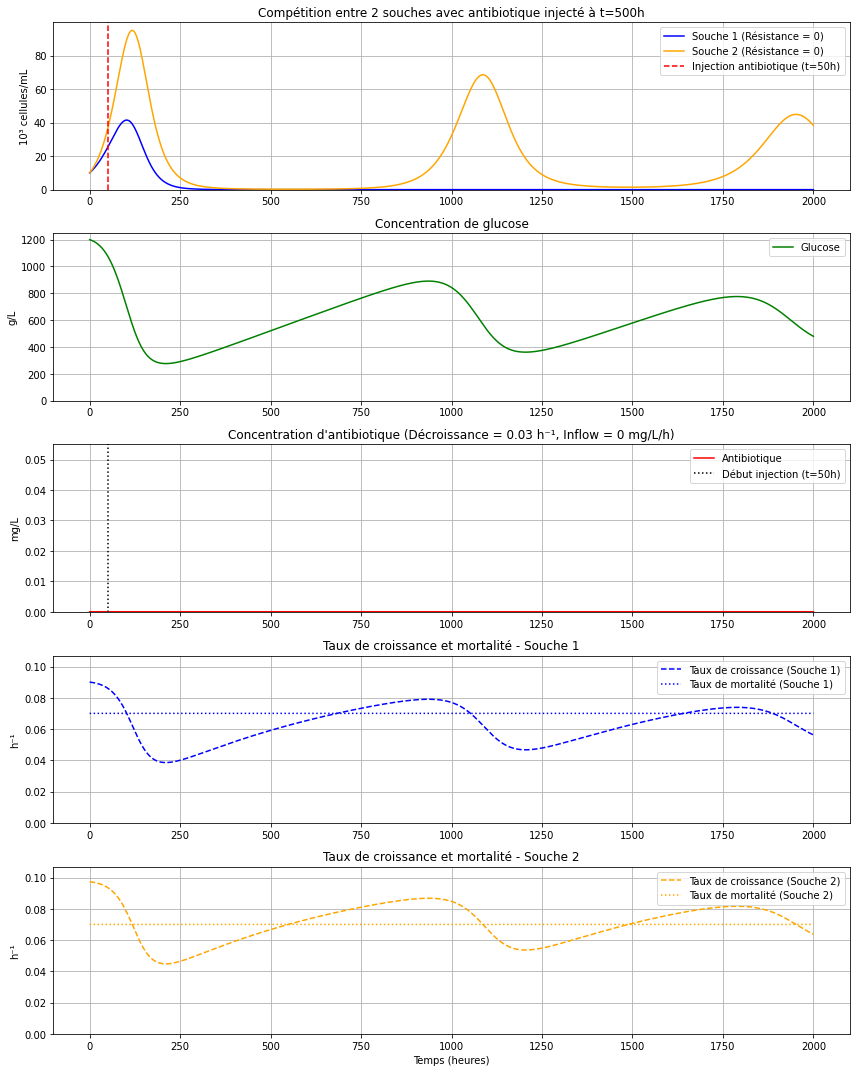

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# PARAMÈTRES POUR LES SOUCHES
# =============================================
# Souche 1
rmax_1 = 0.15      # Taux de croissance maximal (h⁻¹)
m0_1 = 0.07        # Taux de mortalité de base (h⁻¹)
K_1 = 800              # Constante de demi-saturation (g/L)
resistance_1 = 0  # Résistance à l'antibiotique (0 = aucune, 1 = totale)

# Souche 2
rmax_2 = 0.15      # Taux de croissance maximal (h⁻¹)
m0_2 = 0.07        # Taux de mortalité de base (h⁻¹)
K_2 = 650          # Constante de demi-saturation (g/L)
resistance_2 = 0 # Résistance à l'antibiotique

# =============================================
# PARAMÈTRES DU GLUCOSE
# =============================================
initial_glucose = 1200   # Concentration initiale de glucose (g/L)
glucose_inflow = 1      # Flux entrant de glucose (g/L/h)

# =============================================
# PARAMÈTRES DE L'ANTIBIOTIQUE
# =============================================
initial_antibiotic = 0   # Concentration initiale d'antibiotique (mg/L)
antibiotic_intensity = 3 # Intensité (0 = aucun effet, 1 = mortalité doublée)
antibiotic_decay = 0.03    # Taux de décroissance naturelle (h⁻¹)
antibiotic_inflow = 0      # Flux entrant d'antibiotique (mg/L/h)
antibiotic_start_time = 50  # Temps (en heures) avant l'injection

# =============================================
# CONDITIONS INITIALES
# =============================================
C0_1 = 10  # Concentration initiale de la souche 1 (10³ cellules/mL)
C0_2 = 10  # Concentration initiale de la souche 2 (10³ cellules/mL)

# =============================================
# PARAMÈTRES DE LA SIMULATION
# =============================================
dt = 0.1          # Pas de temps (h)
T = 2000          # Durée totale (h)
N_steps = int(T / dt)

# =============================================
# INITIALISATION DES TABLEAUX
# =============================================
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
antibiotic_level = np.zeros(N_steps)
growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)
mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)

# Conditions initiales
C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose
antibiotic_level[0] = 0
growth_rate_1[0] = rmax_1 * glucose_level[0] / (K_1 + glucose_level[0])
growth_rate_2[0] = rmax_2 * glucose_level[0] / (K_2 + glucose_level[0])
mortality_rate_1[0] = m0_1
mortality_rate_2[0] = m0_2

# =============================================
# SIMULATION
# =============================================
for i in range(1, N_steps):
    current_time = i * dt

    # Calcul des taux de croissance
    r_1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    # Mise à jour de l'antibiotique (CORRIGÉ)
    if current_time < antibiotic_start_time:
        antibiotic_level[i] = 0
    else:
        if antibiotic_level[i-1] == 0:  # Premier pas après l'injection
            antibiotic_level[i] = initial_antibiotic
        else:
            antibiotic_level[i] = antibiotic_level[i-1] * (1 - antibiotic_decay * dt) + antibiotic_inflow * dt

    # Effet de l'antibiotique sur la mortalité
    if antibiotic_level[i] > 0:
        antibiotic_effect_1 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 - resistance_1)
        antibiotic_effect_2 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 - resistance_2)
    else:
        antibiotic_effect_1 = 0
        antibiotic_effect_2 = 0

    m_1 = m0_1 * (1 + antibiotic_effect_1)
    m_2 = m0_2 * (1 + antibiotic_effect_2)

    # Mise à jour des populations
    C1[i] = C1[i-1] + dt * (r_1 - m_1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r_2 - m_2) * C2[i-1]

    # Consommation de glucose
    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1])
    glucose_level[i] = glucose_level[i-1] - dt * glucose_consumption + glucose_inflow * dt

    # Stockage des taux
    growth_rate_1[i] = r_1
    growth_rate_2[i] = r_2
    mortality_rate_1[i] = m_1
    mortality_rate_2[i] = m_2

# =============================================
# TEMPS POUR L'AXE DES ABCISSES
# =============================================
time = np.linspace(0, T, N_steps)

# =============================================
# CALCUL DES ÉCHELLES COMMUNES POUR LES TAUX
# =============================================
# Trouver le maximum global pour les taux de croissance et mortalité
max_growth = max(np.max(growth_rate_1), np.max(growth_rate_2))
max_mortality = max(np.max(mortality_rate_1), np.max(mortality_rate_2))
y_max_rates = max(max_growth, max_mortality) * 1.1  # +10% de marge

# =============================================
# TRACÉ DES COURBES
# =============================================
plt.figure(figsize=(12, 15))

# 1. Populations bactériennes
plt.subplot(5, 1, 1)
plt.plot(time, C1, label=f'Souche 1 (Résistance = {resistance_1})', color='blue')
plt.plot(time, C2, label=f'Souche 2 (Résistance = {resistance_2})', color='orange')
plt.axvline(x=antibiotic_start_time, color='red', linestyle='--', label=f'Injection antibiotique (t={antibiotic_start_time}h)')
plt.title('Compétition entre 2 souches avec antibiotique injecté à t=500h')
plt.ylabel('10³ cellules/mL')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 2. Concentration de glucose
plt.subplot(5, 1, 2)
plt.plot(time, glucose_level, label='Glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 3. Concentration d'antibiotique
plt.subplot(5, 1, 3)
plt.plot(time, antibiotic_level, label='Antibiotique', color='red')
plt.axvline(x=antibiotic_start_time, color='black', linestyle=':', label=f'Début injection (t={antibiotic_start_time}h)')
plt.title(f'Concentration d\'antibiotique (Décroissance = {antibiotic_decay} h⁻¹, Inflow = {antibiotic_inflow} mg/L/h)')
plt.ylabel('mg/L')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 4. Taux de croissance et mortalité (Souche 1)
plt.subplot(5, 1, 4)
plt.plot(time, growth_rate_1, label='Taux de croissance (Souche 1)', color='blue', linestyle='--')
plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
plt.title('Taux de croissance et mortalité - Souche 1')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0, top=y_max_rates)  # Échelle commune

# 5. Taux de croissance et mortalité (Souche 2)
plt.subplot(5, 1, 5)
plt.plot(time, growth_rate_2, label='Taux de croissance (Souche 2)', color='orange', linestyle='--')
plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
plt.title('Taux de croissance et mortalité - Souche 2')
plt.xlabel('Temps (heures)')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0, top=y_max_rates)  # Même échelle que le graphique 4

plt.tight_layout()
plt.show()

Nous allons également modifier la durée de la simulation pour la paramétrer à T=2000
    • Décrivez les résultats. 

Lorque la durée est à T=2000 on observe que la souche résistante finit par dominer sur le long terme ( séléction naturelle )

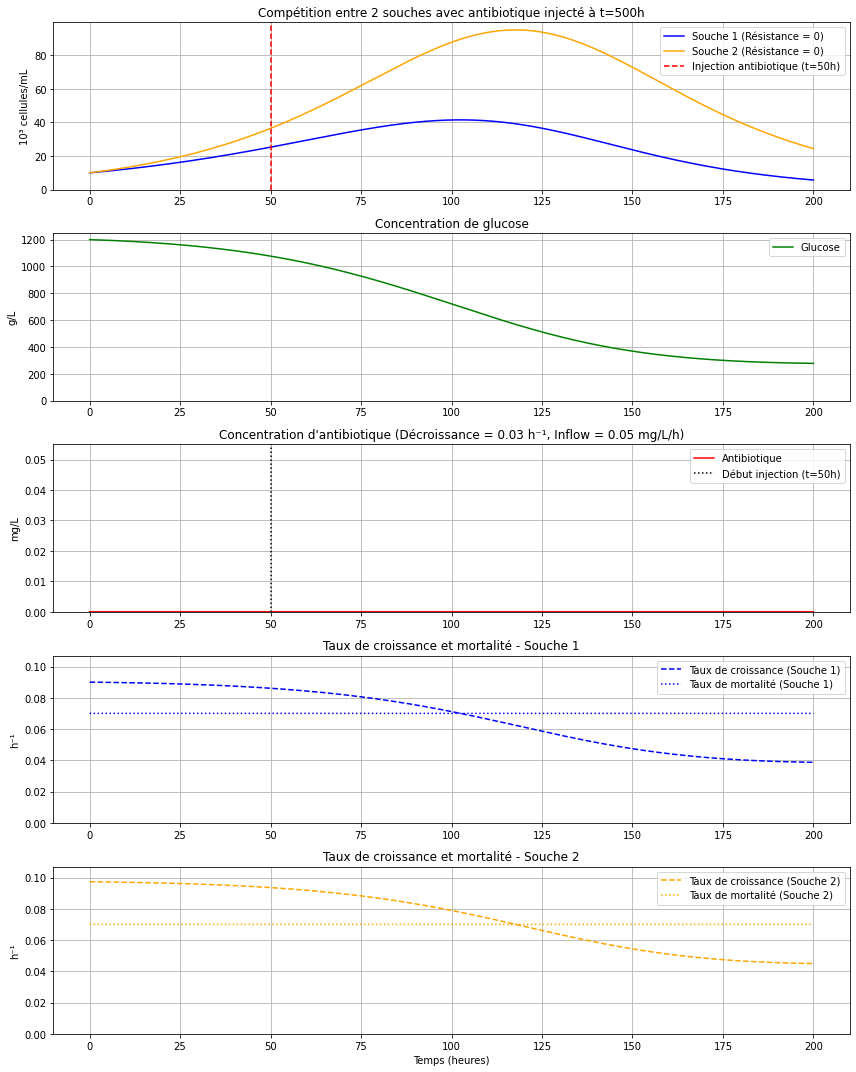

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# PARAMÈTRES POUR LES SOUCHES
# =============================================
# Souche 1
rmax_1 = 0.15      # Taux de croissance maximal (h⁻¹)
m0_1 = 0.07        # Taux de mortalité de base (h⁻¹)
K_1 = 800              # Constante de demi-saturation (g/L)
resistance_1 = 0  # Résistance à l'antibiotique (0 = aucune, 1 = totale)

# Souche 2
rmax_2 = 0.15      # Taux de croissance maximal (h⁻¹)
m0_2 = 0.07        # Taux de mortalité de base (h⁻¹)
K_2 = 650          # Constante de demi-saturation (g/L)
resistance_2 = 0 # Résistance à l'antibiotique

# =============================================
# PARAMÈTRES DU GLUCOSE
# =============================================
initial_glucose = 1200   # Concentration initiale de glucose (g/L)
glucose_inflow = 1      # Flux entrant de glucose (g/L/h)

# =============================================
# PARAMÈTRES DE L'ANTIBIOTIQUE
# =============================================
initial_antibiotic = 0   # Concentration initiale d'antibiotique (mg/L)
antibiotic_intensity = 3 # Intensité (0 = aucun effet, 1 = mortalité doublée)
antibiotic_decay = 0.03    # Taux de décroissance naturelle (h⁻¹)
antibiotic_inflow = 0.05      # Flux entrant d'antibiotique (mg/L/h)
antibiotic_start_time = 50  # Temps (en heures) avant l'injection

# =============================================
# CONDITIONS INITIALES
# =============================================
C0_1 = 10  # Concentration initiale de la souche 1 (10³ cellules/mL)
C0_2 = 10  # Concentration initiale de la souche 2 (10³ cellules/mL)

# =============================================
# PARAMÈTRES DE LA SIMULATION
# =============================================
dt = 0.1          # Pas de temps (h)
T = 200          # Durée totale (h)
N_steps = int(T / dt)

# =============================================
# INITIALISATION DES TABLEAUX
# =============================================
C1 = np.zeros(N_steps)
C2 = np.zeros(N_steps)
glucose_level = np.zeros(N_steps)
antibiotic_level = np.zeros(N_steps)
growth_rate_1 = np.zeros(N_steps)
growth_rate_2 = np.zeros(N_steps)
mortality_rate_1 = np.zeros(N_steps)
mortality_rate_2 = np.zeros(N_steps)

# Conditions initiales
C1[0] = C0_1
C2[0] = C0_2
glucose_level[0] = initial_glucose
antibiotic_level[0] = 0
growth_rate_1[0] = rmax_1 * glucose_level[0] / (K_1 + glucose_level[0])
growth_rate_2[0] = rmax_2 * glucose_level[0] / (K_2 + glucose_level[0])
mortality_rate_1[0] = m0_1
mortality_rate_2[0] = m0_2

# =============================================
# SIMULATION
# =============================================
for i in range(1, N_steps):
    current_time = i * dt

    # Calcul des taux de croissance
    r_1 = rmax_1 * glucose_level[i-1] / (K_1 + glucose_level[i-1])
    r_2 = rmax_2 * glucose_level[i-1] / (K_2 + glucose_level[i-1])

    # Mise à jour de l'antibiotique (CORRIGÉ)
    if current_time < antibiotic_start_time:
        antibiotic_level[i] = 0
    else:
        if antibiotic_level[i-1] == 0:  # Premier pas après l'injection
            antibiotic_level[i] = initial_antibiotic
        else:
            antibiotic_level[i] = antibiotic_level[i-1] * (1 - antibiotic_decay * dt) + antibiotic_inflow * dt

    # Effet de l'antibiotique sur la mortalité
    if antibiotic_level[i] > 0:
        antibiotic_effect_1 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 - resistance_1)
        antibiotic_effect_2 = antibiotic_intensity * (antibiotic_level[i] / initial_antibiotic) * (1 - resistance_2)
    else:
        antibiotic_effect_1 = 0
        antibiotic_effect_2 = 0

    m_1 = m0_1 * (1 + antibiotic_effect_1)
    m_2 = m0_2 * (1 + antibiotic_effect_2)

    # Mise à jour des populations
    C1[i] = C1[i-1] + dt * (r_1 - m_1) * C1[i-1]
    C2[i] = C2[i-1] + dt * (r_2 - m_2) * C2[i-1]

    # Consommation de glucose
    glucose_consumption = (r_1 * C1[i-1] + r_2 * C2[i-1])
    glucose_level[i] = glucose_level[i-1] - dt * glucose_consumption + glucose_inflow * dt

    # Stockage des taux
    growth_rate_1[i] = r_1
    growth_rate_2[i] = r_2
    mortality_rate_1[i] = m_1
    mortality_rate_2[i] = m_2

# =============================================
# TEMPS POUR L'AXE DES ABCISSES
# =============================================
time = np.linspace(0, T, N_steps)

# =============================================
# CALCUL DES ÉCHELLES COMMUNES POUR LES TAUX
# =============================================
# Trouver le maximum global pour les taux de croissance et mortalité
max_growth = max(np.max(growth_rate_1), np.max(growth_rate_2))
max_mortality = max(np.max(mortality_rate_1), np.max(mortality_rate_2))
y_max_rates = max(max_growth, max_mortality) * 1.1  # +10% de marge

# =============================================
# TRACÉ DES COURBES
# =============================================
plt.figure(figsize=(12, 15))

# 1. Populations bactériennes
plt.subplot(5, 1, 1)
plt.plot(time, C1, label=f'Souche 1 (Résistance = {resistance_1})', color='blue')
plt.plot(time, C2, label=f'Souche 2 (Résistance = {resistance_2})', color='orange')
plt.axvline(x=antibiotic_start_time, color='red', linestyle='--', label=f'Injection antibiotique (t={antibiotic_start_time}h)')
plt.title('Compétition entre 2 souches avec antibiotique injecté à t=500h')
plt.ylabel('10³ cellules/mL')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 2. Concentration de glucose
plt.subplot(5, 1, 2)
plt.plot(time, glucose_level, label='Glucose', color='green')
plt.title('Concentration de glucose')
plt.ylabel('g/L')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 3. Concentration d'antibiotique
plt.subplot(5, 1, 3)
plt.plot(time, antibiotic_level, label='Antibiotique', color='red')
plt.axvline(x=antibiotic_start_time, color='black', linestyle=':', label=f'Début injection (t={antibiotic_start_time}h)')
plt.title(f'Concentration d\'antibiotique (Décroissance = {antibiotic_decay} h⁻¹, Inflow = {antibiotic_inflow} mg/L/h)')
plt.ylabel('mg/L')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0)

# 4. Taux de croissance et mortalité (Souche 1)
plt.subplot(5, 1, 4)
plt.plot(time, growth_rate_1, label='Taux de croissance (Souche 1)', color='blue', linestyle='--')
plt.plot(time, mortality_rate_1, label='Taux de mortalité (Souche 1)', color='blue', linestyle=':')
plt.title('Taux de croissance et mortalité - Souche 1')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0, top=y_max_rates)  # Échelle commune

# 5. Taux de croissance et mortalité (Souche 2)
plt.subplot(5, 1, 5)
plt.plot(time, growth_rate_2, label='Taux de croissance (Souche 2)', color='orange', linestyle='--')
plt.plot(time, mortality_rate_2, label='Taux de mortalité (Souche 2)', color='orange', linestyle=':')
plt.title('Taux de croissance et mortalité - Souche 2')
plt.xlabel('Temps (heures)')
plt.ylabel('h⁻¹')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0, top=y_max_rates)  # Même échelle que le graphique 4

plt.tight_layout()
plt.show()

Enfin nous allons simuler une pollution diffuse d’antibiotique en paramétrant antibiotic_inflow = 0.05
    • Décrivez les résultats. 
    • Montrer que la pollution résiduelle d’antibiotique dans l’environnement favorise l’émergence de souches résistantes.


Avec antibiotic_inflow = 0.05 il reste encore un peu d'antibiotique, donc les souches sensibles sont defavorisées et les résistantes sont favorisées

Donc la pollution résiduelle d'antibiotique favorise les souches résistantes car les antibiotiques tuent les souches sensibles ce qui permet aux resitantes de se multiplier davantage 